### Question – Data Preparation & Feature Engineering

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv('/content/smart_home_energy_dataset.csv')
df

,date,household_id,num_occupants,avg_temperature_c,appliance_usage_hours,ac_usage_hours,heater_usage_hours,solar_generation_kwh,humidity_pct,weekday,electricity_price,peak_hour_usage,energy_consumption_kwh
0,2024-01-01,H4,3,34.16833974534194,3.0675175413418794,8.88396239185806,3.1490013376137833,2.2670548965161275,34.05940635582709,Weekend,7.671870466804295,2.2331723743057026,44.48605110332539
1,2024-01-02,H5,4,?,1.0362248337222273,2.6415360048588097,3.9022480403262163,7.169378865991671,74.91809672816574,Weekend,7.034066884169704,2.5848852455860634,23.98516961854523
2,2024-01-03,H1,5,17.425796655378125,11.727061495263113,0.6419329745327762,0.4483965427284007,5.422962599722851,83.93562243488115,Weekend,4.22493590432964,0.14704484841280563,5.194557173531535
3,2024-01-04,H2,5,10.323153703295622,?,1.4216792111086352,1.8567829949347479,18.16304336237473,75.64759581501178,Weekday,3.328546232231245,3.68632130569214,35.585543822857844
4,2024-01-05,H4,3,17.407614606765094,12.564465430297409,2.758373663150283,6.817475753713898,9.958926251823339,32.74695845551902,Weekend,6.351270180286298,3.9790842264866666,31.829892536828748
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,2024-12-21,H2,1,36.90098806272908,6.307622081958831,9.969103324831647,4.485178482778221,17.494855973724533,68.96546600141436,Weekday,3.9186769718707,0.4850310785534423,12.073851418730648
356,2024-12-22,H3,3,21.975818835983315,6.8230170730528545,9.934701620539832,1.463358227437106,14.668120984168189,36.77101935832377,Weekday,?,3.063967110360106,30.579847497790425
357,2024-12-23,H1,3,23.147362239494857,9.667623470948588,9.324610908819048,7.504680824199215,14.442217960593492,39.89062638991311,Weekend,8.177760196680003,0.7613209027635809,48.601851514889454
358,2024-12-24,H2,3,21.610702151667233,9.999630054624209,9.475632363105419,5.773368076825192,5.54084051414751,72.1666662613479,Weekend,5.977293409015839,?,27.80183847744682


In [34]:
print(f"Original shape: {df.shape}")

Original shape: (360, 13)


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   date                    360 non-null    object
 1   household_id            360 non-null    object
 2   num_occupants           360 non-null    object
 3   avg_temperature_c       360 non-null    object
 4   appliance_usage_hours   360 non-null    object
 5   ac_usage_hours          360 non-null    object
 6   heater_usage_hours      360 non-null    object
 7   solar_generation_kwh    360 non-null    object
 8   humidity_pct            360 non-null    object
 9   weekday                 360 non-null    object
 10  electricity_price       360 non-null    object
 11  peak_hour_usage         360 non-null    object
 12  energy_consumption_kwh  360 non-null    object
dtypes: object(13)
memory usage: 36.7+ KB


In [36]:
df = df.replace('?', np.nan)

In [37]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['household_id'] = df['household_id'].astype('category')
df['weekday'] = df['weekday'].astype('category')

numeric_cols = ['num_occupants', 'avg_temperature_c', 'appliance_usage_hours', 'ac_usage_hours', 'heater_usage_hours', 'solar_generation_kwh',
    'humidity_pct', 'electricity_price', 'peak_hour_usage', 'energy_consumption_kwh'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

date                      datetime64[ns]
household_id                    category
num_occupants                    float64
avg_temperature_c                float64
appliance_usage_hours            float64
ac_usage_hours                   float64
heater_usage_hours               float64
solar_generation_kwh             float64
humidity_pct                     float64
weekday                         category
electricity_price                float64
peak_hour_usage                  float64
energy_consumption_kwh           float64
dtype: object


In [38]:
print(df.isnull().sum())

# Numeric columns can be skewed by extreme values so we will fill the null values with Median to reduce outliers
for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# A missing date almost belongs near its rows, so forward fill.
df['date'] = df['date'].ffill()

# Mode fills with the frequently occurring category
for col in ['household_id', 'weekday']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
print(df.isnull().sum())

date                      22
household_id              16
num_occupants             16
avg_temperature_c         19
appliance_usage_hours     14
ac_usage_hours            18
heater_usage_hours        15
solar_generation_kwh      23
humidity_pct              17
weekday                   15
electricity_price         24
peak_hour_usage           10
energy_consumption_kwh    21
dtype: int64
date                      0
household_id              0
num_occupants             0
avg_temperature_c         0
appliance_usage_hours     0
ac_usage_hours            0
heater_usage_hours        0
solar_generation_kwh      0
humidity_pct              0
weekday                   0
electricity_price         0
peak_hour_usage           0
energy_consumption_kwh    0
dtype: int64


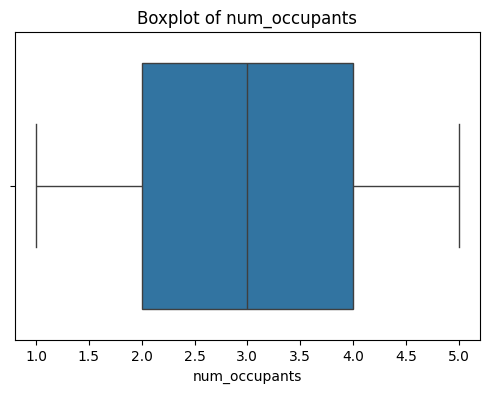

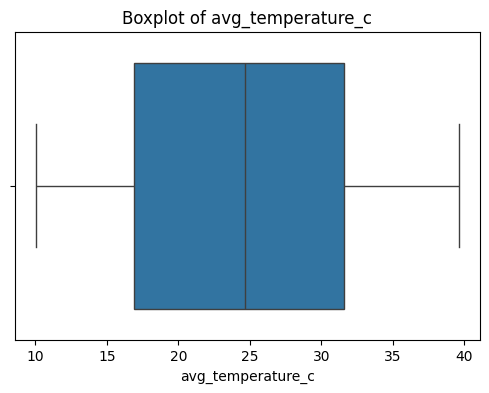

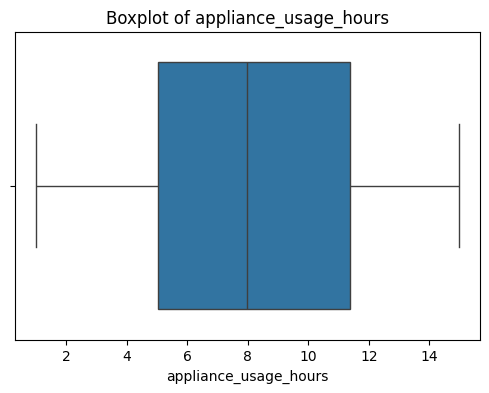

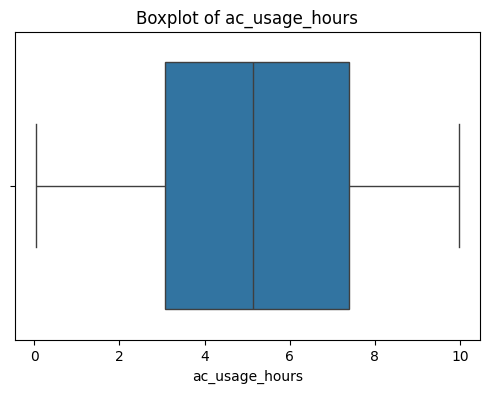

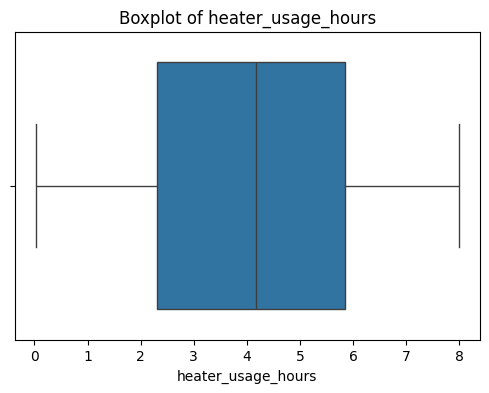

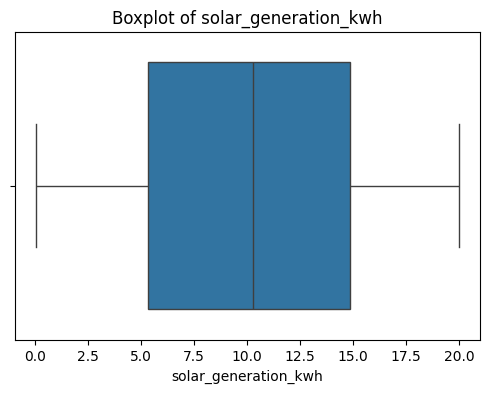

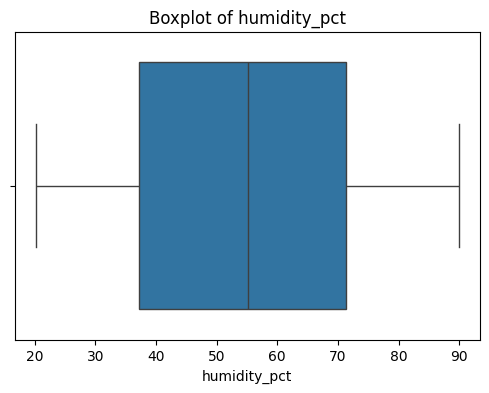

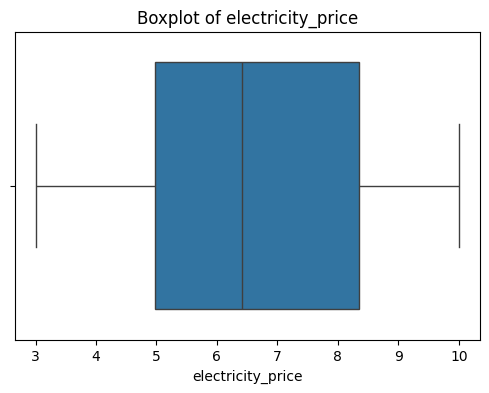

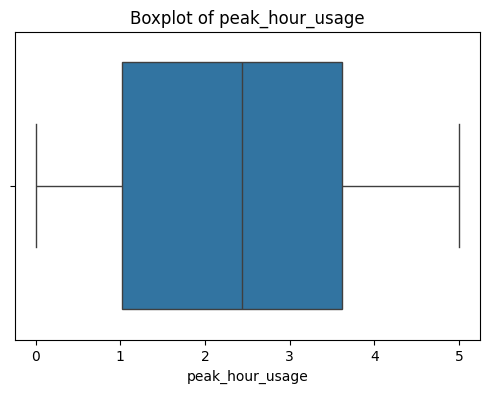

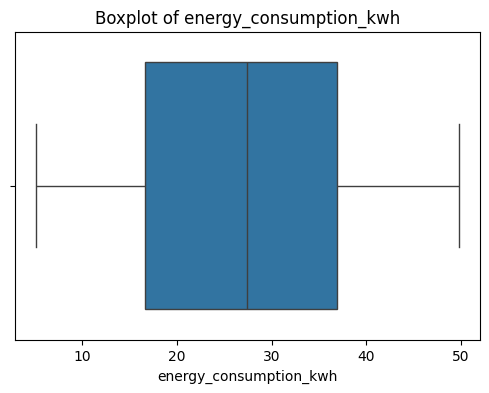

In [39]:
# Check for outliers :->
numeric_cols = ['num_occupants', 'avg_temperature_c', 'appliance_usage_hours', 'ac_usage_hours', 'heater_usage_hours', 'solar_generation_kwh',
    'humidity_pct', 'electricity_price', 'peak_hour_usage', 'energy_consumption_kwh']
for col in numeric_cols:
  plt.figure(figsize=(6, 4))
  sns.boxplot(x=df[col])
  plt.title(f'Boxplot of {col}')
  plt.show()

In [40]:
# Removing outliers :->
def outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

outlier_cols = ['appliance_usage_hours', 'ac_usage_hours', 'energy_consumption_kwh']
for col in outlier_cols:
    df = outliers_iqr(df, col)

In [41]:
# Feature 1: total_usage_hours
df['total_usage_hours'] = (df['appliance_usage_hours'] + df['ac_usage_hours'] + df['heater_usage_hours'])
print("To captures total electrical load per day across all devices.")

# Feature 2: temperature_effect
df['temperature_effect'] = (df['avg_temperature_c'] - 22).clip(lower=0)
print("To measures heat stress above the 22°C comfort baseline.")

# Feature 3: net_energy_usage
df['net_energy_usage'] = df['energy_consumption_kwh'] - df['solar_generation_kwh']
print("To represents actual grid dependency.")

To captures total electrical load per day across all devices.
To measures heat stress above the 22°C comfort baseline.
To represents actual grid dependency.


In [42]:
df.head()

,date,household_id,num_occupants,avg_temperature_c,appliance_usage_hours,ac_usage_hours,heater_usage_hours,solar_generation_kwh,humidity_pct,weekday,electricity_price,peak_hour_usage,energy_consumption_kwh,total_usage_hours,temperature_effect,net_energy_usage
0,2024-01-01,H4,3.0,34.168340,3.067518,8.883962,3.149001,2.267055,34.059406,Weekend,7.671870,2.233172,44.486051,15.100481,12.16834,42.218996
1,2024-01-02,H5,4.0,24.648470,1.036225,2.641536,3.902248,7.169379,74.918097,Weekend,7.034067,2.584885,23.985170,7.580009,2.64847,16.815791
2,2024-01-03,H1,5.0,17.425797,11.727061,0.641933,0.448397,5.422963,83.935622,Weekend,4.224936,0.147045,5.194557,12.817391,0.00000,-0.228405
3,2024-01-04,H2,5.0,10.323154,7.971690,1.421679,1.856783,18.163043,75.647596,Weekday,3.328546,3.686321,35.585544,11.250152,0.00000,17.422500
4,2024-01-05,H4,3.0,17.407615,12.564465,2.758374,6.817476,9.958926,32.746958,Weekend,6.351270,3.979084,31.829893,22.140315,0.00000,21.870966


### Question – Regression Modeling (Energy Prediction)

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [49]:
# Target variable
target = 'energy_consumption_kwh'
feature = ['num_occupants', 'avg_temperature_c', 'appliance_usage_hours', 'ac_usage_hours', 'heater_usage_hours', 'solar_generation_kwh', 'humidity_pct', 'electricity_price', 'peak_hour_usage', 'total_usage_hours', 'temperature_effect']

X = df[feature]
y = df[target]

print(f"Target variable  : {target}")
print(f"Feature columns  : {X}")
print(f"Total samples    : {len(df)}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Target variable  : energy_consumption_kwh
Feature columns  :      num_occupants  avg_temperature_c  appliance_usage_hours  ac_usage_hours  \
0              3.0          34.168340               3.067518        8.883962   
1              4.0          24.648470               1.036225        2.641536   
2              5.0          17.425797              11.727061        0.641933   
3              5.0          10.323154               7.971690        1.421679   
4              3.0          17.407615              12.564465        2.758374   
..             ...                ...                    ...             ...   
355            1.0          36.900988               6.307622        9.969103   
356            3.0          21.975819               6.823017        9.934702   
357            3.0          23.147362               9.667623        9.324611   
358            3.0          21.610702               9.999630        9.475632   
359            1.0          16.752456               6.05318

In [50]:
models = {
    'Linear Regression'       : LinearRegression(),
    'Decision Tree Regressor' : DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor' : RandomForestRegressor(n_estimators=100, random_state=42)
}

trained_models  = {}
predictions     = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred              = model.predict(X_test)
    trained_models[name]  = model
    predictions[name]     = y_pred
    print(f"{name} trained")

Linear Regression trained
Decision Tree Regressor trained
Random Forest Regressor trained


In [55]:
results = {}

for name, y_pred in predictions.items():
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

results_df = pd.DataFrame(results).T.round(4)
results_df

,MAE,RMSE,R2
Linear Regression,9.9251,11.8759,-0.0328
Decision Tree Regressor,15.1810,18.0597,-1.3884
Random Forest Regressor,10.2387,12.1385,-0.0790


In [57]:
# Compare model performance and identify the best-performing model.

best_model_name = results_df['R2'].idxmax()
best = results_df.loc[best_model_name]

print(f"Best Model : {best_model_name}")
print(f"MAE : {best['MAE']:.4f}")
print(f"RMSE : {best['RMSE']:.4f}")
print(f"R2 Score : {best['R2']:.4f}")

Best Model : Linear Regression
MAE : 9.9251
RMSE : 11.8759
R2 Score : -0.0328


### Question – Statistical Analysis (Regression Insight)

In [59]:
from scipy import stats

In [60]:
# Perform a hypothesis test: H0: Temperature has no effect on energy consumption
# Apply: Choose an appropriate statistical test and justify

# H0: Temperature has no effect on energy consumption
# H1: Temperature has a significant effect on energy consumption
# Test: Pearson Correlation t-test as Both variables are continuous & numeric

r, p_value = stats.pearsonr(df['avg_temperature_c'], df['energy_consumption_kwh'])

if p_value < 0.05:
    print(f"Result : Reject H0")
else:
    print(f"Result : Fail to Reject H0")


Result : Fail to Reject H0


In [62]:
# Compute: 95% confidence interval for average energy consumption

mean   = df['energy_consumption_kwh'].mean()
se     = stats.sem(df['energy_consumption_kwh'])
ci     = stats.t.interval(0.95, df = len(df) - 1, loc = mean, scale = se)
print(f"95% CI lies between : ({ci[0]}, {ci[1]}) kWh")

95% CI lies between : (25.669261499059807, 28.169047671444865) kWh


In [63]:
# Perform: Correlation analysis between:
# temperature
# appliance usage
# energy consumption

corr_cols = ['avg_temperature_c', 'appliance_usage_hours', 'energy_consumption_kwh']
corr_matrix = df[corr_cols].corr()

print(corr_matrix.round(4))

                        avg_temperature_c  appliance_usage_hours  \
avg_temperature_c                  1.0000                -0.0863   
appliance_usage_hours             -0.0863                 1.0000   
energy_consumption_kwh             0.0922                -0.0567   

                        energy_consumption_kwh  
avg_temperature_c                       0.0922  
appliance_usage_hours                  -0.0567  
energy_consumption_kwh                  1.0000  


In [ ]:
# Explain: Overfitting vs Underfitting in regression models :->

# Overfitting:
# 1.) Model learns training data TOO well including noise
# 2.) High R2 on train, very low R2 on test
# 3.) Example: Deep Decision Tree memorizes every training row
# Underfitting:
# 1.) Model is TOO simple to capture patterns
# 2.) Low R2 on both train and test
# 3.) Example: Linear Regression on non-linear data

### Question – Time Series Forecasting (Energy Demand)

In [64]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [66]:
print(df.columns)

Index(['date', 'household_id', 'num_occupants', 'avg_temperature_c',
       'appliance_usage_hours', 'ac_usage_hours', 'heater_usage_hours',
       'solar_generation_kwh', 'humidity_pct', 'weekday', 'electricity_price',
       'peak_hour_usage', 'energy_consumption_kwh', 'total_usage_hours',
       'temperature_effect', 'net_energy_usage'],
      dtype='object')


In [67]:
# Handle missing values
df = df.dropna()

daily_data = df.resample('D', on='date')['energy_consumption_kwh'].sum()

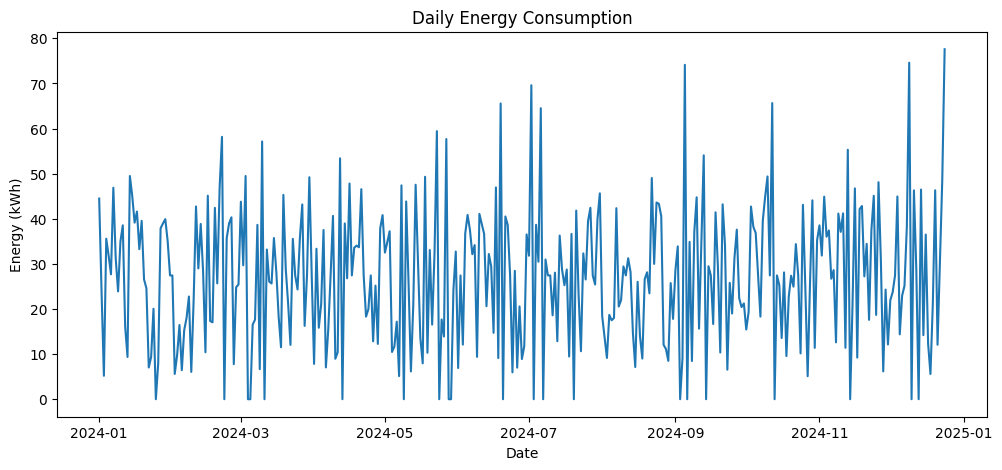

In [68]:
plt.figure(figsize=(12,5))
plt.plot(daily_data)
plt.title("Daily Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy in (kWh)")
plt.show()

In [69]:
result = adfuller(daily_data)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] > 0.05:
    print("Data is NOT stationary → applying differencing")
    daily_data = daily_data.diff().dropna()

ADF Statistic: -5.698049804460465
p-value: 7.79111259875535e-07


In [70]:
train_size = int(len(daily_data) * 0.8)

train = daily_data[:train_size]
test  = daily_data[train_size:]

In [71]:
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

In [72]:
predictions = model_fit.forecast(steps=len(test))

mae  = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))

print("Model Evaluation:")
print("MAE :", mae)
print("RMSE:", rmse)

Model Evaluation:
MAE : 12.456936546000096
RMSE: 15.908932715410636


In [75]:
future_forecast = model_fit.forecast(steps=10)
print(f"Next 10 Days Forecast: {future_forecast}")

Next 10 Days Forecast: 2024-10-14    30.628151
2024-10-15    25.947253
2024-10-16    26.662634
2024-10-17    26.553302
2024-10-18    26.570012
2024-10-19    26.567458
2024-10-20    26.567848
2024-10-21    26.567789
2024-10-22    26.567798
2024-10-23    26.567796
Freq: D, Name: predicted_mean, dtype: float64


In [77]:
# Explain how this forecast can help in energy planning and pricing decisions.
# It can helps predict future energy demand.
# It helps in pricing strategies.
# Ensuring grid in avoiding blackouts and power-cuts.